In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_csv('pakistan_floods.csv',encoding='latin1')
print(df.head())
print(df.columns.tolist())

        Region  Year  Total_deaths  M_D  F_D  C_D  Total_injured  M_I  F_I  \
0         AJ&K  2010            85   52   21   12            210  120   60   
1  Balochistan  2010           198  110   55   33            420  230  110   
2           GB  2010            41   25   10    6             95   55   25   
3          ICT  2010             3    2    1    0             12    7    3   
4           KP  2010           412  230  110   72            890  490  240   

   C_I  Roads_damaged_km  Bridges_damaged  Houses_damaged  Livestock_damaged  \
0   30               120                8           12500               3200   
1   80              2100               18           48000             210000   
2   15               280               72            3200               1200   
3    2                15                0             800                100   
4  160              3200              198          120000              45000   

   Affected_population  
0               320000  


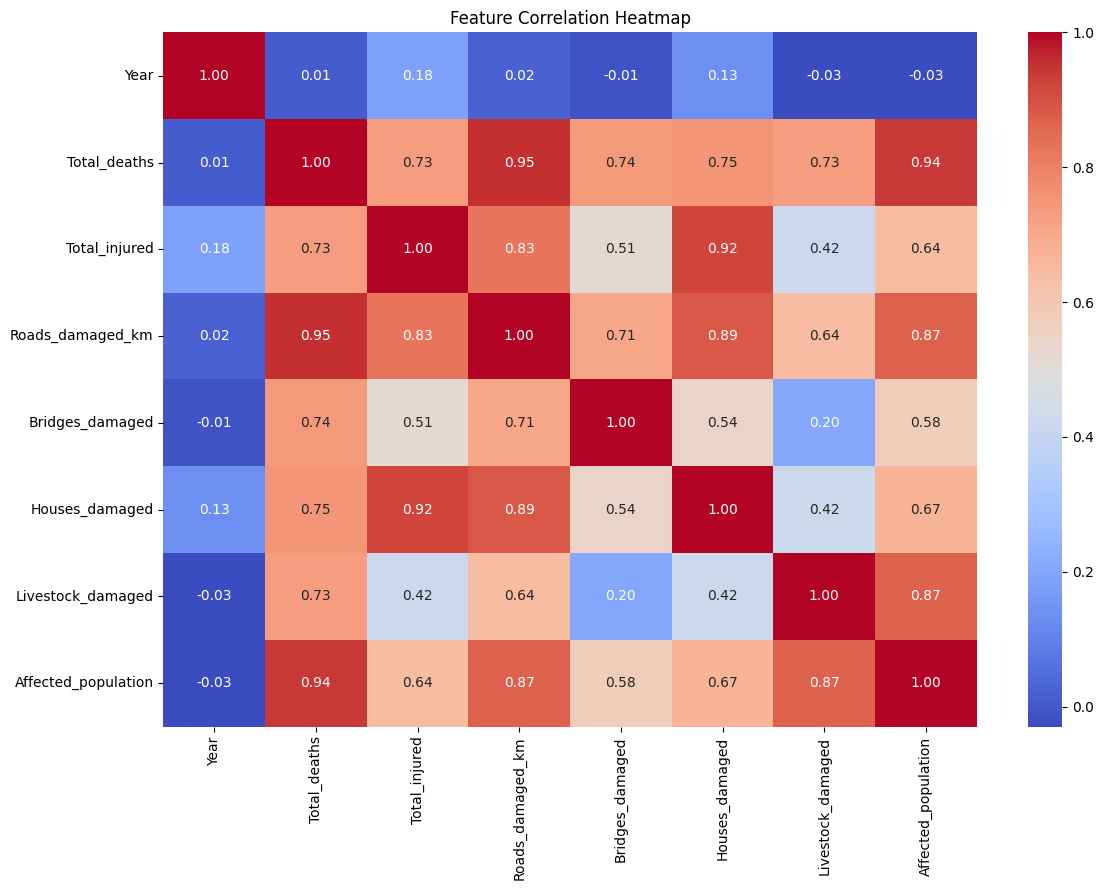

In [31]:
# ===EXPLORATORY DATA ANALYSIS ===
cols_to_plot = ['Year', 'Total_deaths', 'Total_injured', 'Roads_damaged_km',
                'Bridges_damaged', 'Houses_damaged', 'Livestock_damaged', 'Affected_population']

plt.figure(figsize=(12, 9))
sns.heatmap(df[cols_to_plot].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('Correlation_Heatmap.png')
plt.show()

In [22]:
# ===FEATURE & TARGET SELECTION ===
features = ['Year', 'Total_deaths', 'Total_injured', 'Roads_damaged_km',
            'Bridges_damaged', 'Houses_damaged', 'Livestock_damaged']
target = 'Affected_population'

X = df[features]
y = df[target]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:,.0f}")

R² Score : 0.6319
RMSE     : 1,380,902


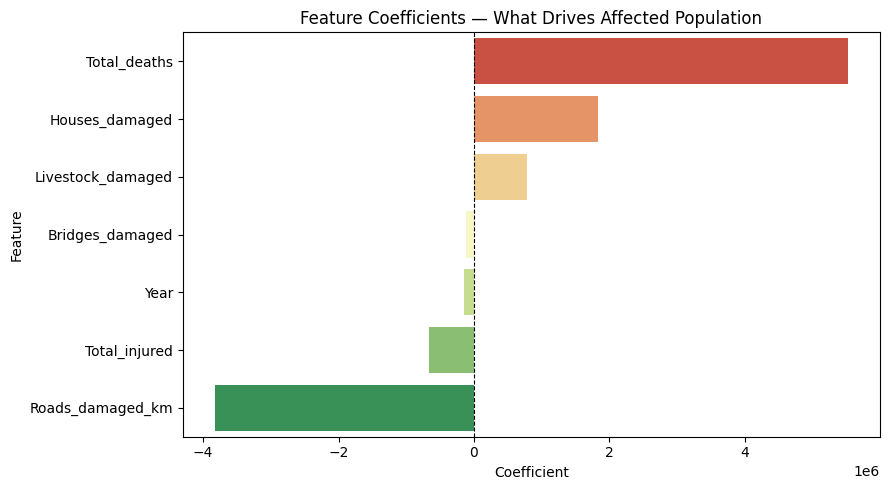

In [32]:
# ===FEATURE IMPORTANCE (coefficients) ===
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature',
            hue='Feature', palette='RdYlGn', legend=False)
plt.title('Feature Coefficients — What Drives Affected Population')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('FC_Population.png')
plt.show()

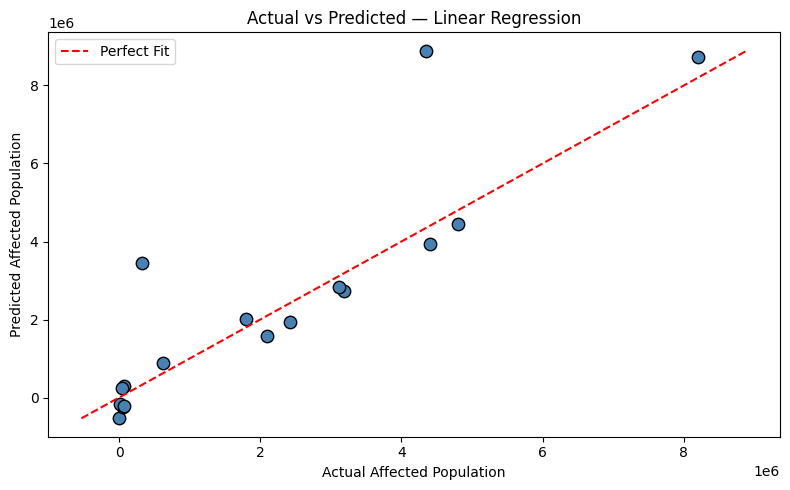

In [33]:
# ===SCATTER — Actual vs Predicted ===
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='steelblue', s=80, edgecolors='black')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')

plt.xlabel('Actual Affected Population')
plt.ylabel('Predicted Affected Population')
plt.title('Actual vs Predicted — Linear Regression')
plt.legend()
plt.tight_layout()
plt.savefig('LR.png')
plt.show()

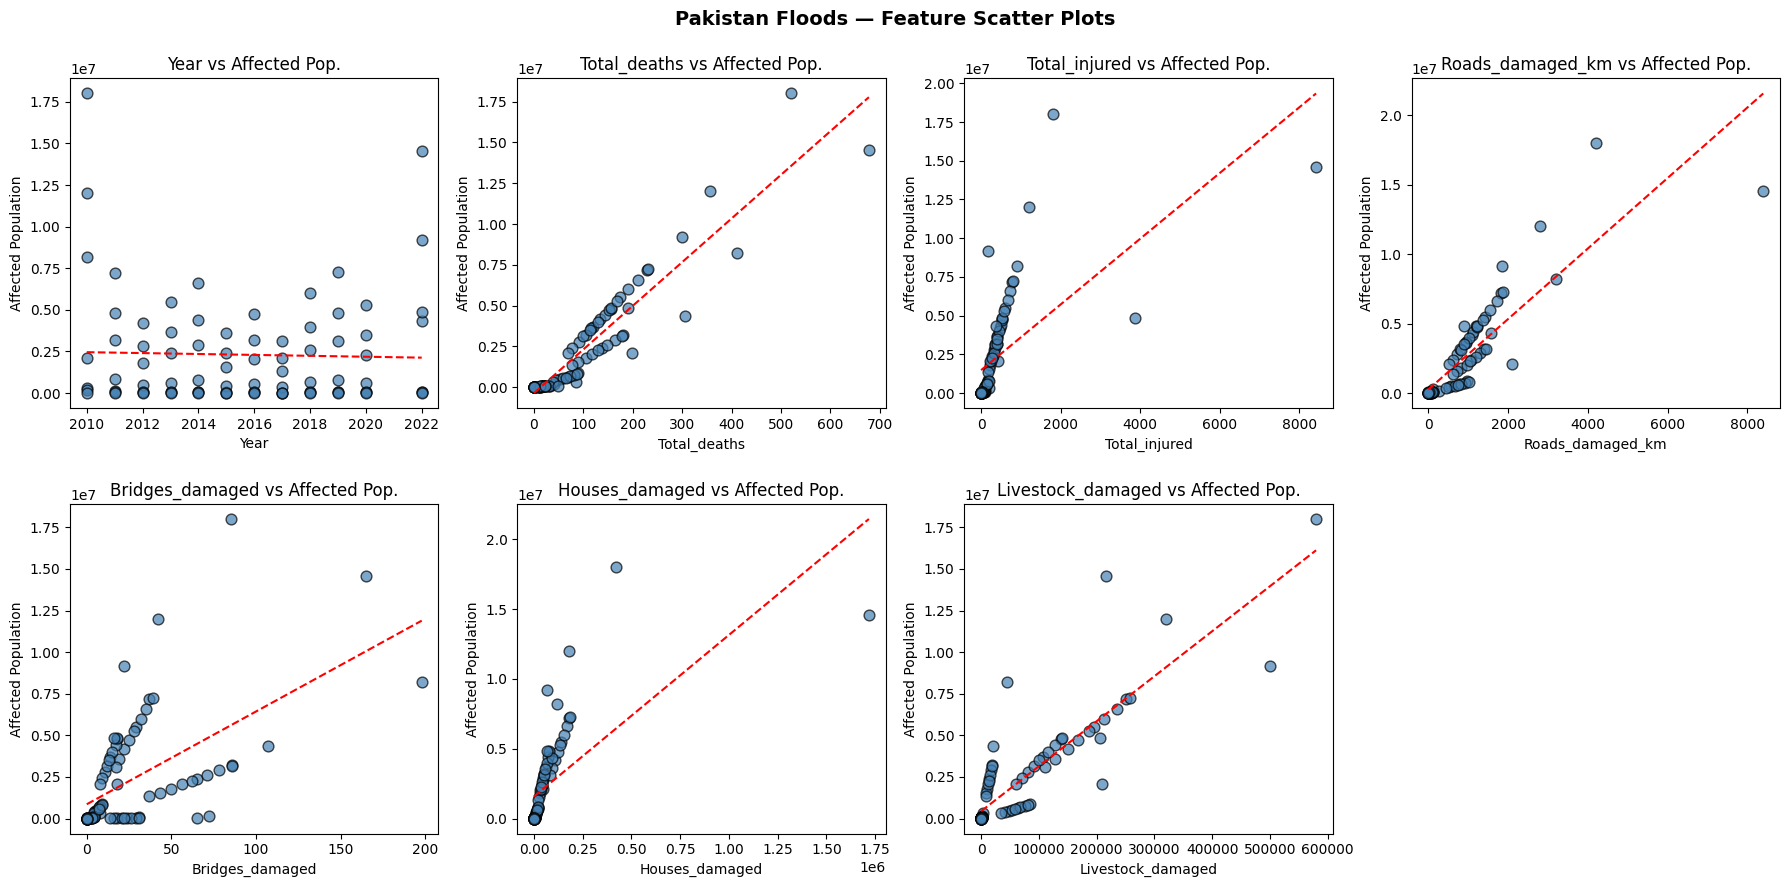

In [34]:
# ===SCATTER GRID — Each feature vs Affected Population ===
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Affected_population'],
                    color='steelblue', s=60, edgecolors='black', alpha=0.7)

    m, b = np.polyfit(df[feature], df['Affected_population'], 1)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linestyle='--', linewidth=1.5)

    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Affected Population')
    axes[i].set_title(f'{feature} vs Affected Pop.')


axes[-1].set_visible(False)

plt.suptitle('Pakistan Floods — Feature Scatter Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_plot_floods.png')
plt.show()

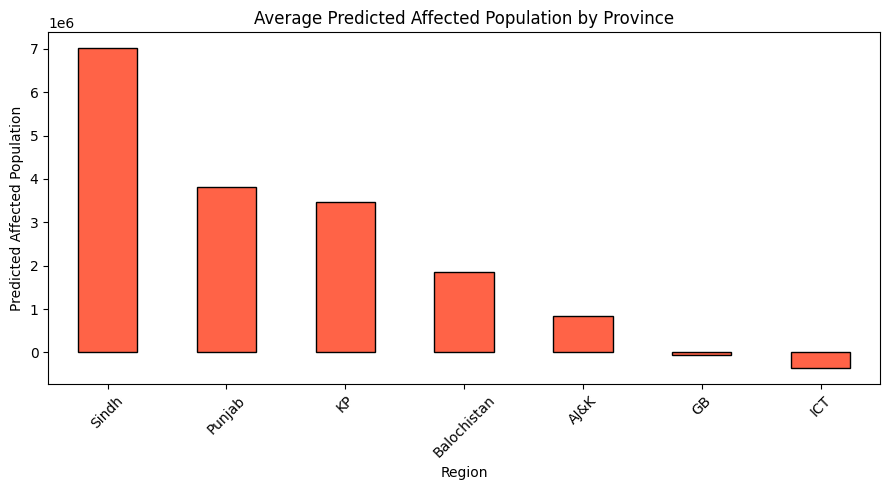


--- Province Risk Ranking ---
Region
Sindh          7.011663e+06
Punjab         3.822106e+06
KP             3.462768e+06
Balochistan    1.856430e+06
AJ&K           8.469866e+05
GB            -6.559344e+04
ICT           -3.525812e+05
Name: Predicted_affected, dtype: float64


In [35]:
# ===PROVINCE RISK RANKING (avg predicted across all years) ===
X_all_scaled = scaler.transform(X)
df['Predicted_affected'] = model.predict(X_all_scaled)

risk_ranking = df.groupby('Region')['Predicted_affected'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
risk_ranking.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Average Predicted Affected Population by Province')
plt.ylabel('Predicted Affected Population')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Affected_Population_byProvince.png')
plt.show()

print("\n--- Province Risk Ranking ---")
print(risk_ranking)

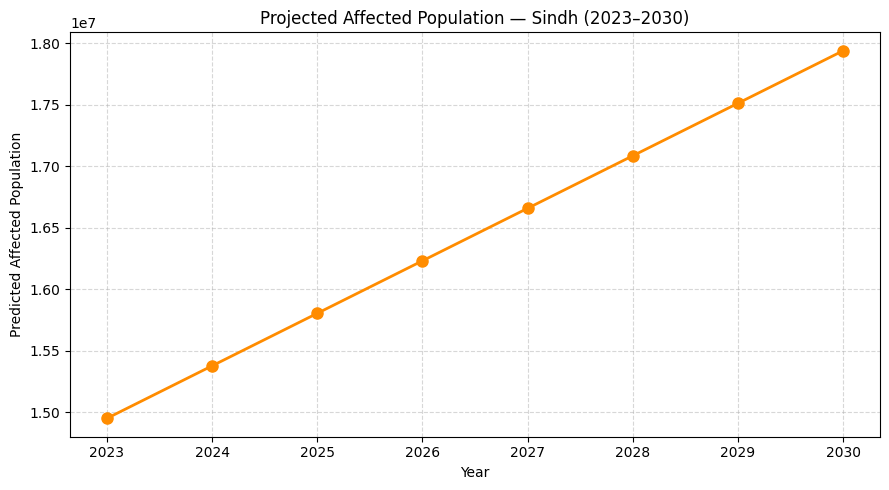

   Year  Predicted_affected
0  2023        1.495241e+07
1  2024        1.537914e+07
2  2025        1.580587e+07
3  2026        1.623261e+07
4  2027        1.665934e+07
5  2028        1.708607e+07
6  2029        1.751281e+07
7  2030        1.793954e+07


In [36]:
# === FUTURE PREDICTIONS (2023–2030) ===
future_years = list(range(2023, 2031))

# === Use Sindh's 2022 values as a worst-case baseline
sindh_2022 = df[df['Region'] == 'Sindh'].sort_values('Year').iloc[-1]

future_rows = []
for i, yr in enumerate(future_years):
    scale = 1 + (i * 0.03) 
    future_rows.append({
        'Year': yr,
        'Total_deaths':    sindh_2022['Total_deaths']    * scale,
        'Total_injured':   sindh_2022['Total_injured']   * scale,
        'Roads_damaged_km':sindh_2022['Roads_damaged_km']* scale,
        'Bridges_damaged': sindh_2022['Bridges_damaged'] * scale,
        'Houses_damaged':  sindh_2022['Houses_damaged']  * scale,
        'Livestock_damaged':sindh_2022['Livestock_damaged']* scale,
    })

future_df = pd.DataFrame(future_rows)
future_scaled = scaler.transform(future_df[features])
future_df['Predicted_affected'] = model.predict(future_scaled)

plt.figure(figsize=(9, 5))
plt.plot(future_df['Year'], future_df['Predicted_affected'],
         marker='o', color='darkorange', linewidth=2, markersize=8)
plt.title('Projected Affected Population — Sindh (2023–2030)')
plt.xlabel('Year')
plt.ylabel('Predicted Affected Population')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Sindh_Affected.png')
plt.show()

print(future_df[['Year', 'Predicted_affected']])

In [ ]:
#- Sindh is the highest risk province (14.5M affected in 2022)
#- Houses_damaged and Roads_damaged_km are the strongest predictors
#- Model R² = X, RMSE = Y
#- Projected affected population grows from X (2023) to Y (2030)